In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, NelsonAalenFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts
import numpy as np
from sklearn.metrics import r2_score
    
plt.style.use('seaborn-v0_8-whitegrid')
sns.set(font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

In [4]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

## DOPASUJMY KRZYWĄ KAPLANA-MEIERA

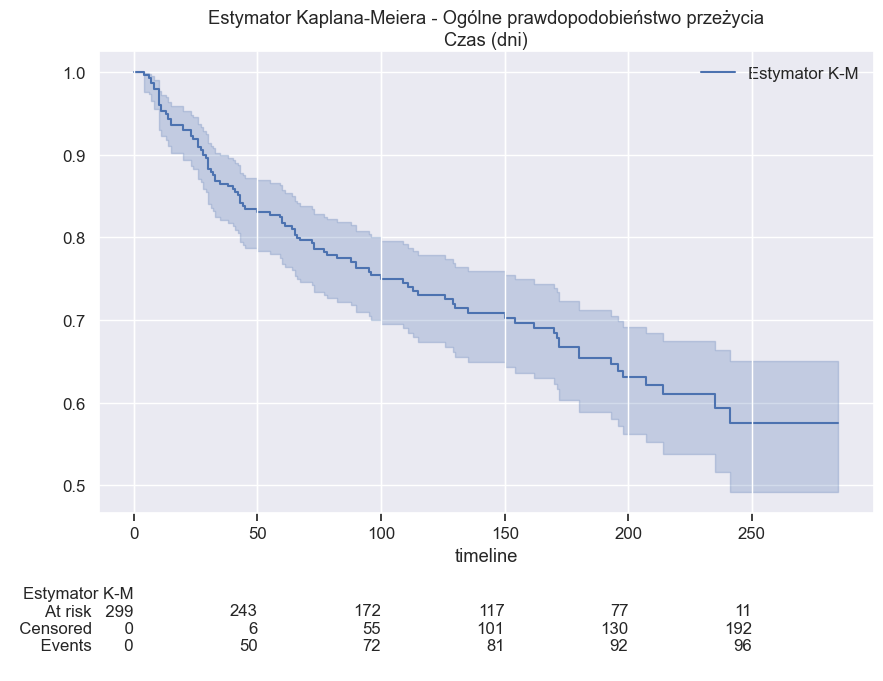

In [5]:
## Krzywa Kaplana-Meiera z przedziałami ufności i tabelą osób narażonych na ryzyko

kmf = KaplanMeierFitter()
kmf.fit(durations=df['time'], event_observed=df['DEATH_EVENT'], label='Estymator K-M', alpha=0.05)

plt.figure(figsize=(10, 6))
ax = plt.subplot(111)
kmf.plot_survival_function()
add_at_risk_counts(kmf, ax=ax)
plt.title('Estymator Kaplana-Meiera - Ogólne prawdopodobieństwo przeżycia')
plt.xlabel('Czas (dni)')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.grid(True)
plt.show()

In [6]:
full_km_report = kmf.survival_function_.join(kmf.event_table).join(kmf.confidence_interval_).drop(columns=['entrance', 'removed'])
full_km_report = full_km_report.rename(columns={
    'Estymator K-M': 'przeżycie',
    'observed': 'zdarzenia',
    'censored': 'censorowane',
    'at_risk': 'narażeni na ryzyko',
    'Estymator K-M_lower_0.95': 'dolny przedz. ufności',
    'Estymator K-M_upper_0.95': 'górny przedz. ufności'
})
full_km_report['Skumulowana funkcja hazardu'] = -(np.log(full_km_report['przeżycie']))
full_km_report['Skumulowana funkcja hazardu'][0] = 0
display(full_km_report)
# display(full_km_report[full_km_report['zdarzenia']>0])

C:\Users\matma\AppData\Local\Temp\ipykernel_8600\3622096065.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_km_report['Skumulowana funkcja hazardu'][0] = 0


,przeżycie,zdarzenia,censorowane,narażeni na ryzyko,dolny przedz. ufności,górny przedz. ufności,Skumulowana funkcja hazardu
timeline,,,,,,,
0.0,1.000000,0,0,299,1.000000,1.000000,0.000000
4.0,0.996656,1,0,299,0.976498,0.999528,0.003350
6.0,0.993311,1,0,298,0.973522,0.998323,0.006711
7.0,0.986622,2,0,297,0.964751,0.994958,0.013468
8.0,0.979933,2,0,295,0.955881,0.990935,0.020271
...,...,...,...,...,...,...,...
270.0,0.575705,0,2,6,0.491856,0.650723,0.552160
271.0,0.575705,0,1,4,0.491856,0.650723,0.552160
278.0,0.575705,0,1,3,0.491856,0.650723,0.552160


In [7]:
### Funkcja do tworzenia tablicy przeżycia z kodów dostarczonych przez Panią Prowadzącą
def create_life_table(durations, events, intervals=None):

    ### Tworzenie przedziałów automatycznie
    if intervals is None:
        max_duration = max(durations)
        intervals = np.linspace(0, max_duration, 11)[1:]
    
    ### Stworzenie początkowej tablicy życia
    # floor i ceil dodane dla czytelności
    life_table = pd.DataFrame({
        'Początek przedziału': [0] + list(np.ceil(intervals)[:-1]),
        'Koniec przedziału': list(np.floor(intervals)),
        'Środek przedziału (t_jm)': np.zeros(len(intervals)),
        'Szerokość przedziału (b_j)': np.zeros(len(intervals)),
        'Narażeni na ryzyko (n_j)': np.zeros(len(intervals)),
        'Zdarzenia (d_j)': np.zeros(len(intervals)),
        'Cenzorowane (m_j)': np.zeros(len(intervals)),
        'Hazard (h_j)': np.zeros(len(intervals)),
        'Prawdop. zdarzenia (q_j)': np.zeros(len(intervals)),
        'Prawdop. przeżycia przedziału (p_j)': np.zeros(len(intervals)),
        'Przeżycie skumulowane (S(t))': np.zeros(len(intervals)),
    })
    
    ### Obliczanie podstawowych wartości dla przedziałów
    for i, (start, end) in enumerate(zip(life_table['Początek przedziału'], life_table['Koniec przedziału'])):
        # Szerokość przedziału
        life_table.loc[i, 'Szerokość przedziału (b_j)'] = end - start
        # Środek przedziału
        life_table.loc[i, 'Środek przedziału (t_jm)'] = (start + end) / 2
        
        # Zdarzenia i cenzorowania w przedziale
        if i == 0:
            in_interval = (durations <= end)
        else:
            in_interval = (durations > start) & (durations <= end)
        
        life_table.loc[i, 'Zdarzenia (d_j)'] = sum(in_interval & (events == 1))
        life_table.loc[i, 'Cenzorowane (m_j)'] = sum(in_interval & (events == 0))
        
        # Narażeni na ryzyko na początku przedziału
        N_j = sum(durations >= start)
        m_j = life_table.loc[i, 'Cenzorowane (m_j)']
        
        # Efektywnie narażeni na ryzyko (skorygowani o cenzurowanie)
        life_table.loc[i, 'Narażeni na ryzyko (n_j)'] = N_j - m_j / 2
    
    ### Obliczanie funkcji hazardu i przeżycia
    surv_prob = 1.0
    for i in range(len(life_table)):
        n_j = life_table.loc[i, 'Narażeni na ryzyko (n_j)']
        d_j = life_table.loc[i, 'Zdarzenia (d_j)']
        b_j = life_table.loc[i, 'Szerokość przedziału (b_j)']
        
        if n_j > 0:
            # Prawdopodobieństwo zajścia zdarzenia w przedziale
            q_j = d_j / n_j
            life_table.loc[i, 'Prawdop. zdarzenia (q_j)'] = q_j
            
            # Prawdopodobieństwo przeżycia przedziału
            p_j = 1 - q_j
            life_table.loc[i, 'Prawdop. przeżycia przedziału (p_j)'] = p_j
            
            # Funkcja hazardu
            hazard = d_j / (b_j * n_j)
            life_table.loc[i, 'Hazard (h_j)'] = hazard
        else:
            life_table.loc[i, 'Prawdop. zdarzenia (q_j)'] = 0
            life_table.loc[i, 'Prawdop. przeżycia przedziału (p_j)'] = 1
            life_table.loc[i, 'Hazard (h_j)'] = 0
        
        # Skumulowana funkcja przeżycia
        surv_prob *= life_table.loc[i, 'Prawdop. przeżycia przedziału (p_j)']
        life_table.loc[i, 'Przeżycie skumulowane (S(t))'] = surv_prob
    
    return life_table

In [8]:
life_table_auto = create_life_table(df['time'], df['DEATH_EVENT'])
print("\nTablica życia z automatycznymi przedziałami:")
display(life_table_auto)


Tablica życia z automatycznymi przedziałami:


,Początek przedziału,Koniec przedziału,Środek przedziału (t_jm),Szerokość przedziału (b_j),Narażeni na ryzyko (n_j),Zdarzenia (d_j),Cenzorowane (m_j),Hazard (h_j),Prawdop. zdarzenia (q_j),Prawdop. przeżycia przedziału (p_j),Przeżycie skumulowane (S(t))
0,0.0,28.0,14.0,28.0,297.5,30.0,3.0,0.003601,0.100840,0.899160,0.899160
1,29.0,57.0,43.0,28.0,264.0,20.0,4.0,0.002706,0.075758,0.924242,0.831042
2,57.0,85.0,71.0,28.0,227.5,15.0,25.0,0.002355,0.065934,0.934066,0.776248
3,86.0,114.0,100.0,28.0,180.0,9.0,40.0,0.001786,0.050000,0.950000,0.737435
4,114.0,142.0,128.0,28.0,142.5,5.0,15.0,0.001253,0.035088,0.964912,0.711560
5,143.0,171.0,157.0,28.0,124.0,5.0,12.0,0.001440,0.040323,0.959677,0.682868
6,171.0,199.0,185.0,28.0,100.0,7.0,28.0,0.002500,0.070000,0.930000,0.635068
7,200.0,228.0,214.0,28.0,61.5,2.0,33.0,0.001161,0.032520,0.967480,0.614415
8,228.0,256.0,242.0,28.0,26.5,2.0,31.0,0.002695,0.075472,0.924528,0.568044
9,257.0,285.0,271.0,28.0,5.0,0.0,8.0,0.000000,0.000000,1.000000,0.568044


## PORÓWNANIA KRZYWYCH K-M

In [41]:


def analiza_nieparametryczna_grup(df, group_col, labels_dict, title):
    """
    Funkcja wykonuje kompleksową analizę nieparametryczną:
    - Wykresy KM dla wszystkich grup
    - Testy globalne (Log-rank, Wilcoxon)
    - Porównania parami (jeśli grupy > 2)
    """
    plt.figure(figsize=(10, 7))
    ax = plt.subplot(111)
    
    unique_groups = sorted(df[group_col].unique())
    group_data = {}
    
    # 1. Rysowanie krzywych
    for val in unique_groups:
        mask = (df[group_col] == val)
        label = labels_dict.get(val, f'Grupa {val}')
        
        kmf = KaplanMeierFitter()
        kmf.fit(df['time'][mask], df['DEATH_EVENT'][mask], label=label)
        kmf.plot_survival_function(ax=ax, ci_show=True)
        
        # Zapisujemy dane do testów parami
        group_data[val] = {
            'time': df['time'][mask],
            'event': df['DEATH_EVENT'][mask],
            'label': label
        }
    
    # 2. Testy Globalne
    res_lr = multivariate_logrank_test(df['time'], df[group_col], df['DEATH_EVENT'])
    res_wil = multivariate_logrank_test(df['time'], df[group_col], df['DEATH_EVENT'], weightings="wilcoxon")
    
    txt_lr = f"Test Log-rank: p-value = {res_lr.p_value:.4f}"
    txt_wil = f"Test Wilcoxon: p-value = {res_wil.p_value:.4f}"
    
    # 3. Formatowanie wykresu
    plt.title(f'Krzywe przeżycia K-M: {title}', fontsize=14, pad=20)
    plt.xlabel('Czas (dni)')
    plt.ylabel('Prawdopodobieństwo przeżycia S(t)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.text(0.05, 0.1, f"{txt_lr}\n{txt_wil}", transform=ax.transAxes, fontsize=11,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))
    plt.tight_layout()
    plt.show()

    # 4. Wydruk wyników i Porównania Parami (analogicznie do prowadzącej)
    print(f"\n--- WYNIKI DLA ZMIENNEJ: {title} ---")
    print(txt_lr)
    print(txt_wil)
    
    if len(unique_groups) > 2:
        print("\nPorównania parami (Log-rank):")
        pair_results = []
        for i, g1 in enumerate(unique_groups[:-1]):
            for g2 in unique_groups[i+1:]:
                test = logrank_test(group_data[g1]['time'], group_data[g2]['time'], 
                                    group_data[g1]['event'], group_data[g2]['event'])
                pair_results.append({
                    'Grupa A': group_data[g1]['label'],
                    'Grupa B': group_data[g2]['label'],
                    'p-value': test.p_value
                })
        df_pairs = pd.DataFrame(pair_results).sort_values(by='p-value')
        display(df_pairs.style.format({'p-value': '{:.6f}'}))
    print("-" * 60)



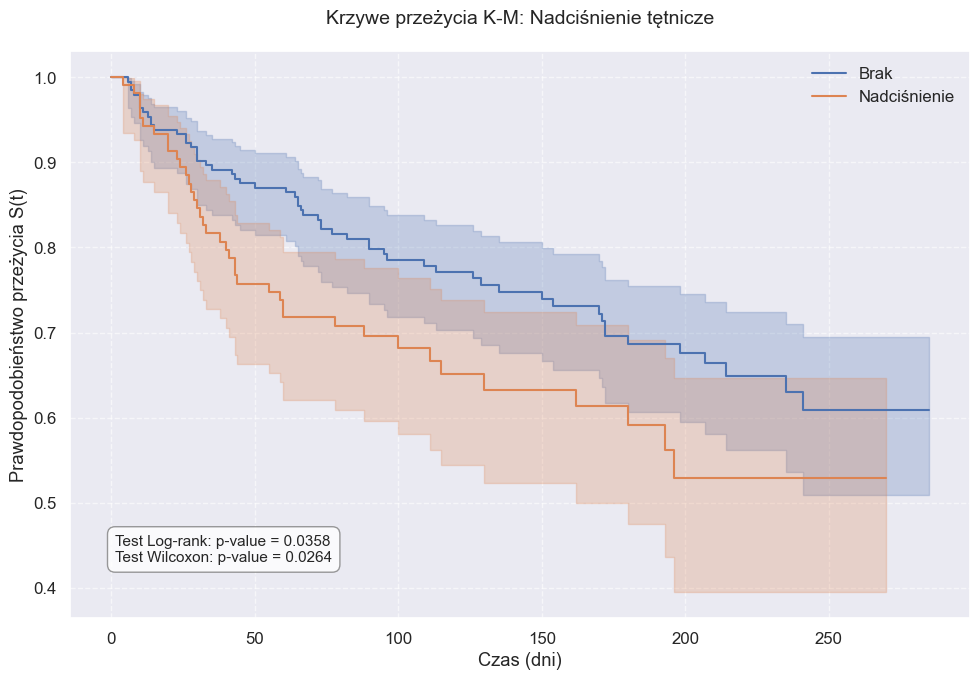


--- WYNIKI DLA ZMIENNEJ: Nadciśnienie tętnicze ---
Test Log-rank: p-value = 0.0358
Test Wilcoxon: p-value = 0.0264
------------------------------------------------------------


In [42]:
analiza_nieparametryczna_grup(df, 'high_blood_pressure', {0: 'Brak', 1: 'Nadciśnienie'}, 'Nadciśnienie tętnicze')

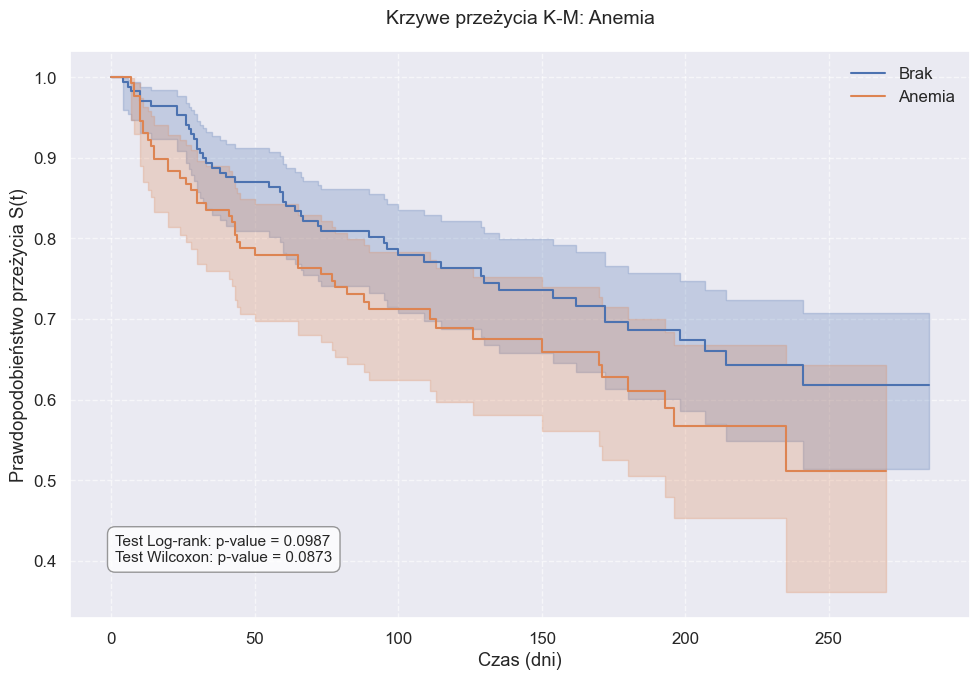


--- WYNIKI DLA ZMIENNEJ: Anemia ---
Test Log-rank: p-value = 0.0987
Test Wilcoxon: p-value = 0.0873
------------------------------------------------------------


In [43]:
analiza_nieparametryczna_grup(df, 'anaemia', {0: 'Brak', 1: 'Anemia'}, 'Anemia')

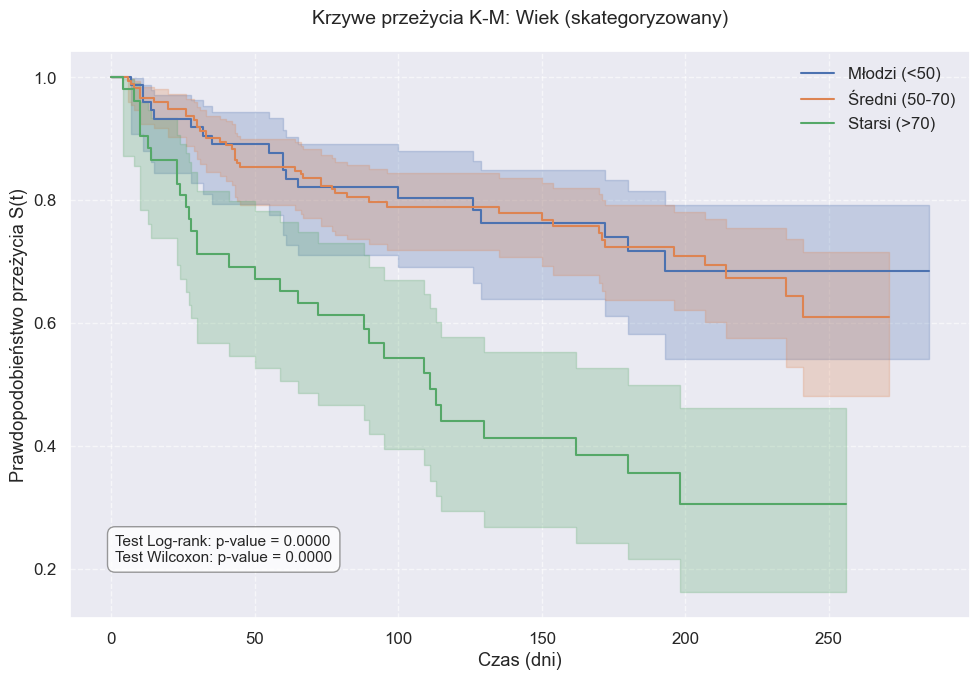


--- WYNIKI DLA ZMIENNEJ: Wiek (skategoryzowany) ---
Test Log-rank: p-value = 0.0000
Test Wilcoxon: p-value = 0.0000

Porównania parami (Log-rank):


,Grupa A,Grupa B,p-value
2,Średni (50-70),Starsi (>70),0.000001
1,Młodzi (<50),Starsi (>70),0.000067
0,Młodzi (<50),Średni (50-70),0.780771


------------------------------------------------------------


In [44]:
df['age_cat'] = pd.cut(df['age'], bins=[0, 50, 70, 100], labels=[0, 1, 2])
analiza_nieparametryczna_grup(df, 'age_cat', {0: 'Młodzi (<50)', 1: 'Średni (50-70)', 2: 'Starsi (>70)'}, 'Wiek (skategoryzowany)')


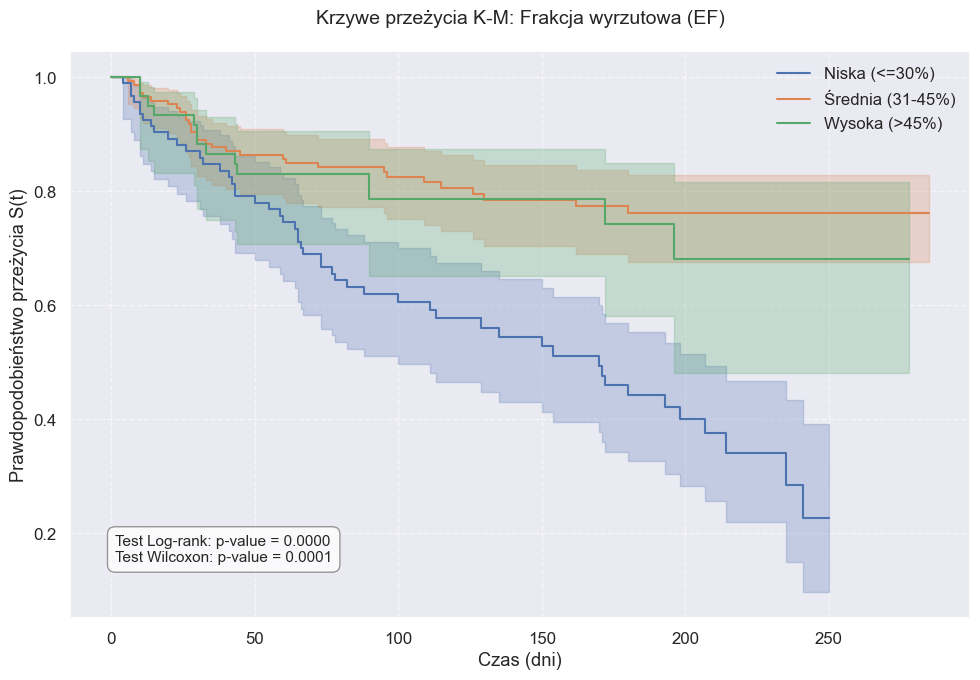


--- WYNIKI DLA ZMIENNEJ: Frakcja wyrzutowa (EF) ---
Test Log-rank: p-value = 0.0000
Test Wilcoxon: p-value = 0.0001

Porównania parami (Log-rank):


,Grupa A,Grupa B,p-value
0,Niska (<=30%),Średnia (31-45%),0.000000
1,Niska (<=30%),Wysoka (>45%),0.002246
2,Średnia (31-45%),Wysoka (>45%),0.549470


------------------------------------------------------------


In [45]:
df['ef_cat'] = pd.cut(df['ejection_fraction'], bins=[0, 30, 45, 100], labels=[0, 1, 2])
analiza_nieparametryczna_grup(df, 'ef_cat', {0: 'Niska (<=30%)', 1: 'Średnia (31-45%)', 2: 'Wysoka (>45%)'}, 'Frakcja wyrzutowa (EF)')

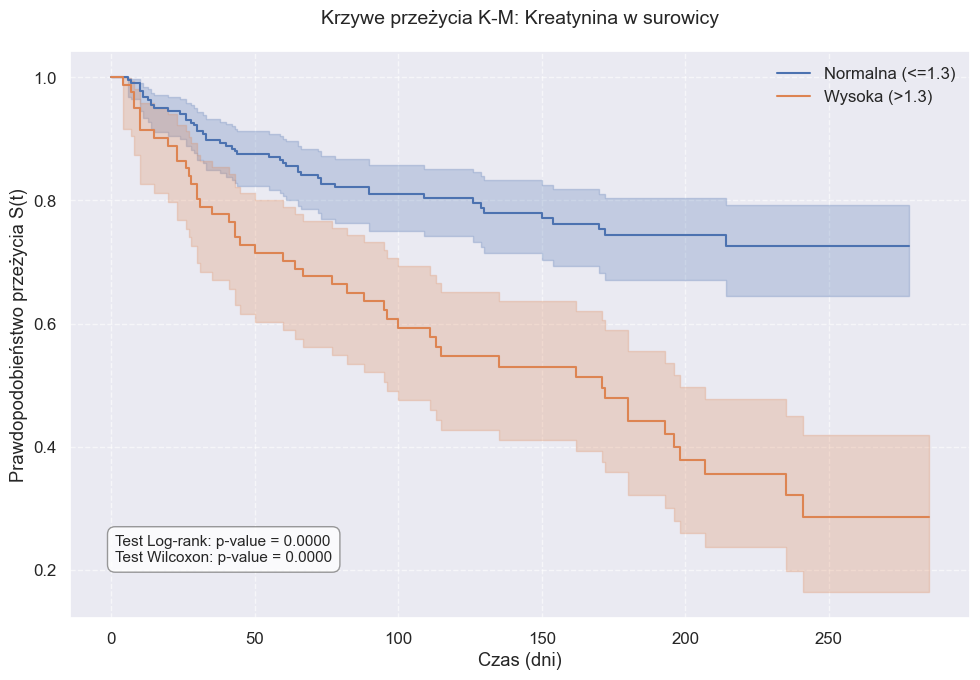


--- WYNIKI DLA ZMIENNEJ: Kreatynina w surowicy ---
Test Log-rank: p-value = 0.0000
Test Wilcoxon: p-value = 0.0000
------------------------------------------------------------


In [46]:
df['creatinine_cat'] = pd.cut(df['serum_creatinine'], bins=[0, 1.3, 10], labels=[0, 1])
analiza_nieparametryczna_grup(df, 'creatinine_cat', {0: 'Normalna (<=1.3)', 1: 'Wysoka (>1.3)'}, 'Kreatynina w surowicy')

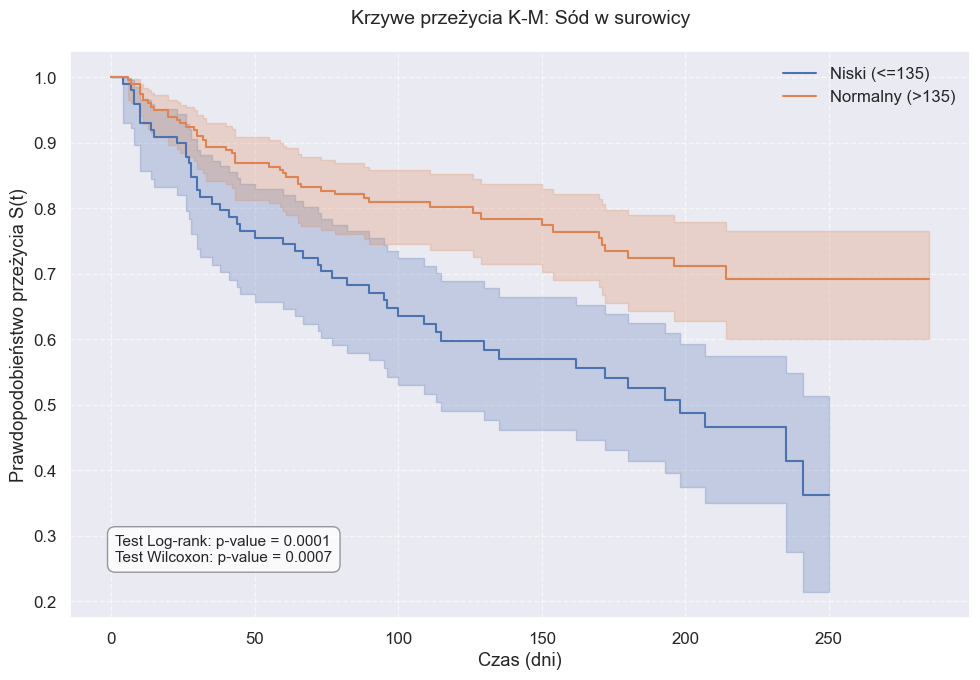


--- WYNIKI DLA ZMIENNEJ: Sód w surowicy ---
Test Log-rank: p-value = 0.0001
Test Wilcoxon: p-value = 0.0007
------------------------------------------------------------


In [47]:
df['sodium_cat'] = pd.cut(df['serum_sodium'], bins=[0, 135, 150], labels=[0, 1])
analiza_nieparametryczna_grup(df, 'sodium_cat', {0: 'Niski (<=135)', 1: 'Normalny (>135)'}, 'Sód w surowicy')

## KSZTAŁT FUNKCJI HAZARDU

In [11]:
def ksztalt_hazardu_populacja(df, time_col='time', event_col='DEATH_EVENT', bandwidths=[30, 60, 100, 150]):
    """
    Funkcja rysuje wygładzoną funkcję hazardu (Estymator Nelsona-Aalena) 
    dla całej populacji z różnymi wartościami parametru bandwidth.
    """
    naf = NelsonAalenFitter()
    naf.fit(df[time_col], df[event_col])

    plt.figure(figsize=(16, 8)) 
    for i, bw in enumerate(bandwidths):
        plt.subplot(2, 2, i + 1)
        hazard_x = naf.smoothed_hazard_(bandwidth=bw)
        plt.plot(hazard_x.index, hazard_x.values, 'r-', lw=2)
        plt.title(f'Wygładzona funkcja hazardu (bandwidth={bw})')
        plt.xlabel('Czas (dni)')
        plt.ylabel('Hazard')
        plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

def ksztalt_hazardu_grup(df, group_col, labels_dict, title, time_col='time', event_col='DEATH_EVENT', bandwidth=100):
    """
    Funkcja rysuje i porównuje wygładzone funkcje hazardu (Estymator Nelsona-Aalena)
    między zdefiniowanymi podgrupami na jednym wykresie.
    """
    plt.figure(figsize=(10, 7))
    ax = plt.subplot(111)
    
    unique_groups = sorted(df[group_col].unique())
    
    for val in unique_groups:
        mask = (df[group_col] == val)
        label = labels_dict.get(val, f'Grupa {val}')
        
        naf_grupa = NelsonAalenFitter()
        naf_grupa.fit(df[time_col][mask], df[event_col][mask])
        
        hazard_grupa = naf_grupa.smoothed_hazard_(bandwidth=bandwidth)
        plt.plot(hazard_grupa.index, hazard_grupa.values, lw=2, label=label)

    plt.title(f'Wygładzona funkcja hazardu: {title}', fontsize=14, pad=20)
    plt.xlabel('Czas (dni)')
    plt.ylabel('Hazard')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


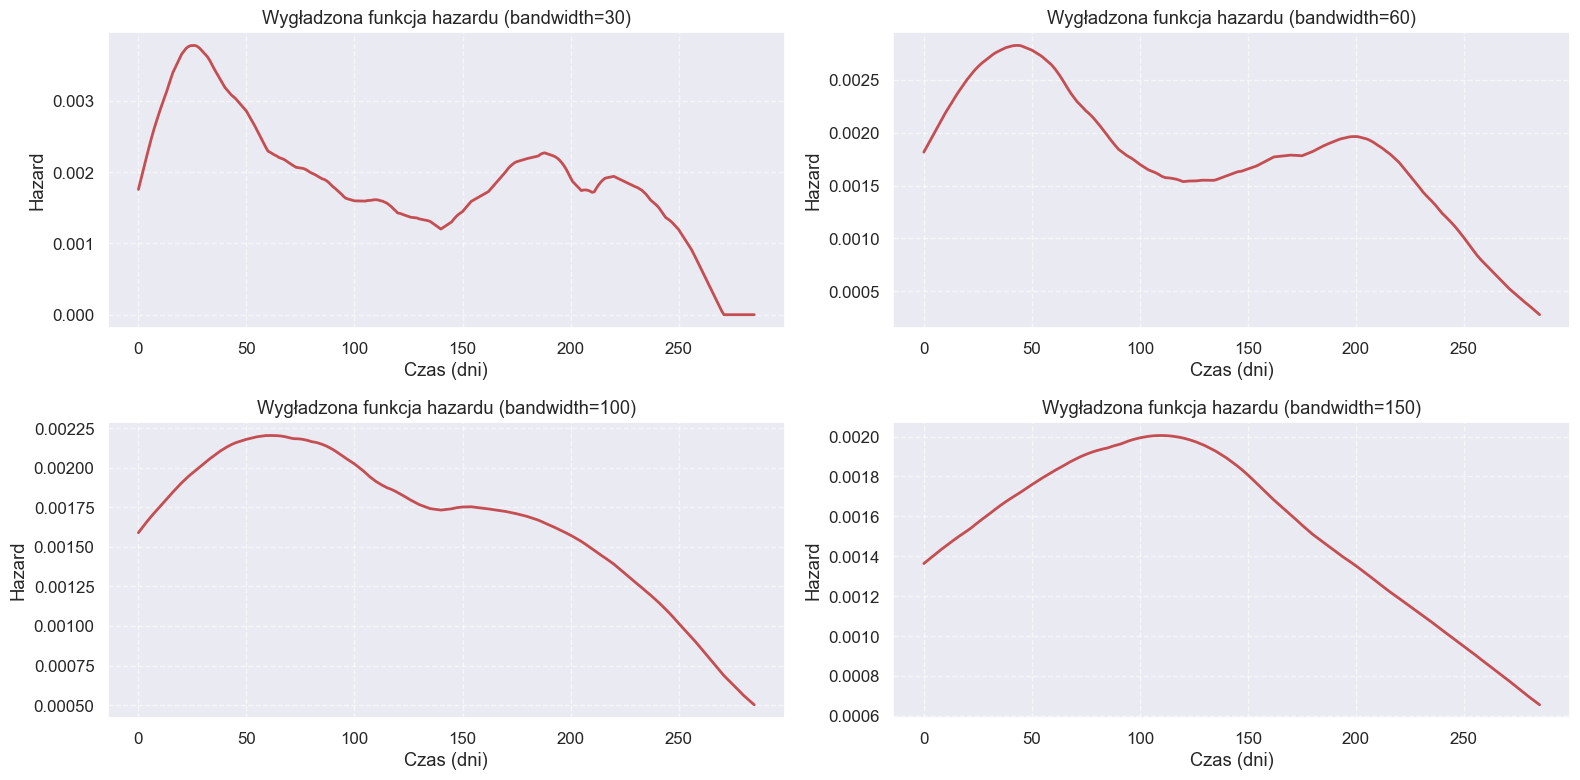

In [13]:
ksztalt_hazardu_populacja(df, time_col='time', event_col='DEATH_EVENT', bandwidths=[30, 60, 100, 150])

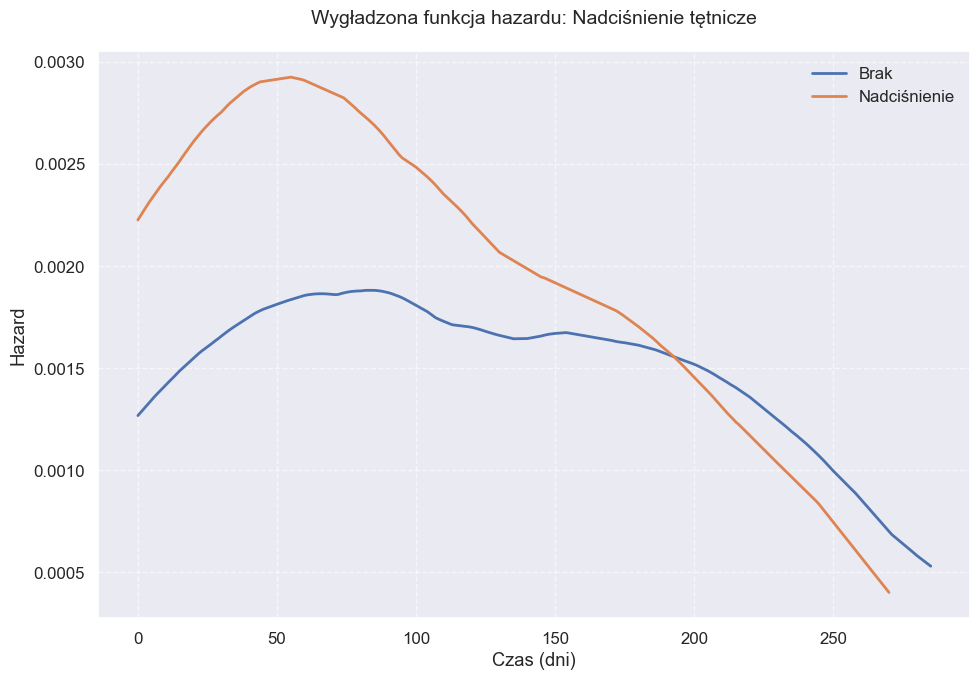

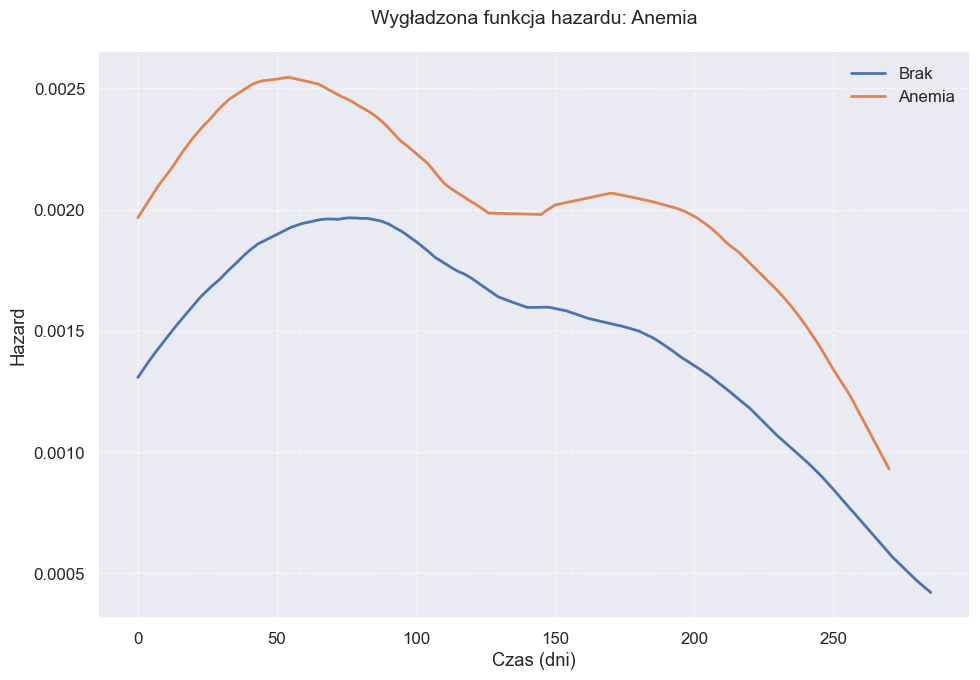

In [14]:
ksztalt_hazardu_grup(df, 'high_blood_pressure', {0: 'Brak', 1: 'Nadciśnienie'}, 'Nadciśnienie tętnicze')
ksztalt_hazardu_grup(df, 'anaemia', {0: 'Brak', 1: 'Anemia'}, 'Anemia')

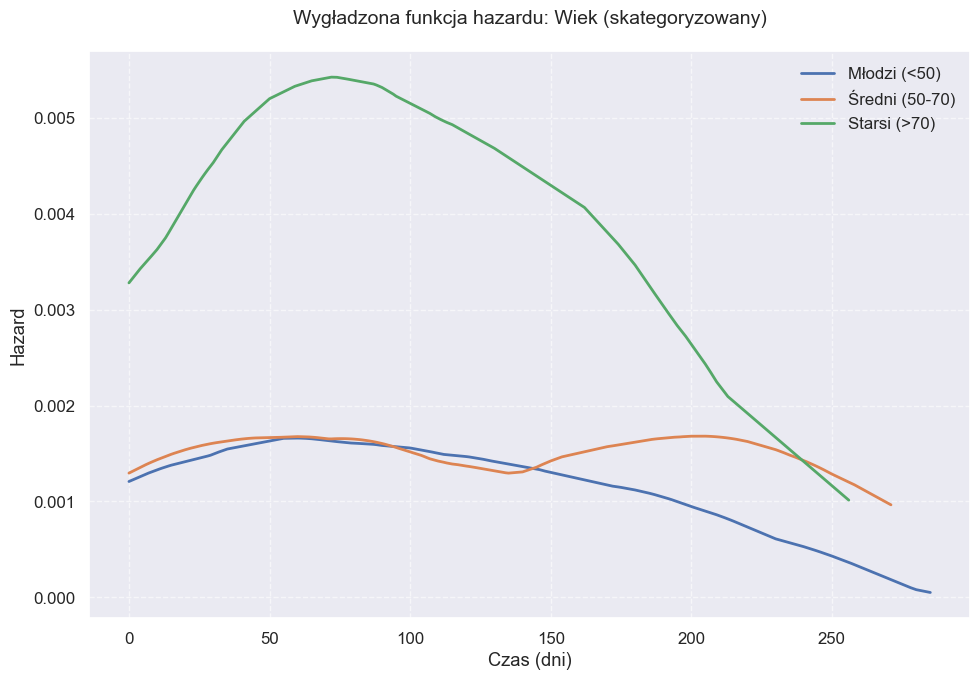

In [15]:
df['age_cat'] = pd.cut(df['age'], bins=[0, 50, 70, 100], labels=[0, 1, 2])
ksztalt_hazardu_grup(df, 'age_cat', {0: 'Młodzi (<50)', 1: 'Średni (50-70)', 2: 'Starsi (>70)'}, 'Wiek (skategoryzowany)')

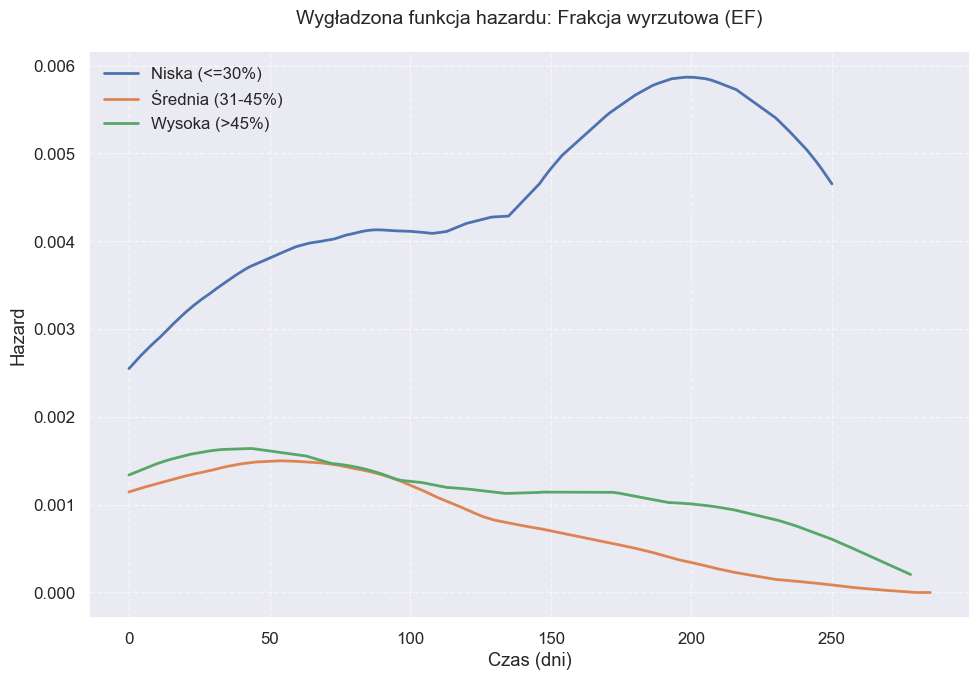

In [16]:
df['ef_cat'] = pd.cut(df['ejection_fraction'], bins=[0, 30, 45, 100], labels=[0, 1, 2])
ksztalt_hazardu_grup(df, 'ef_cat', {0: 'Niska (<=30%)', 1: 'Średnia (31-45%)', 2: 'Wysoka (>45%)'}, 'Frakcja wyrzutowa (EF)')

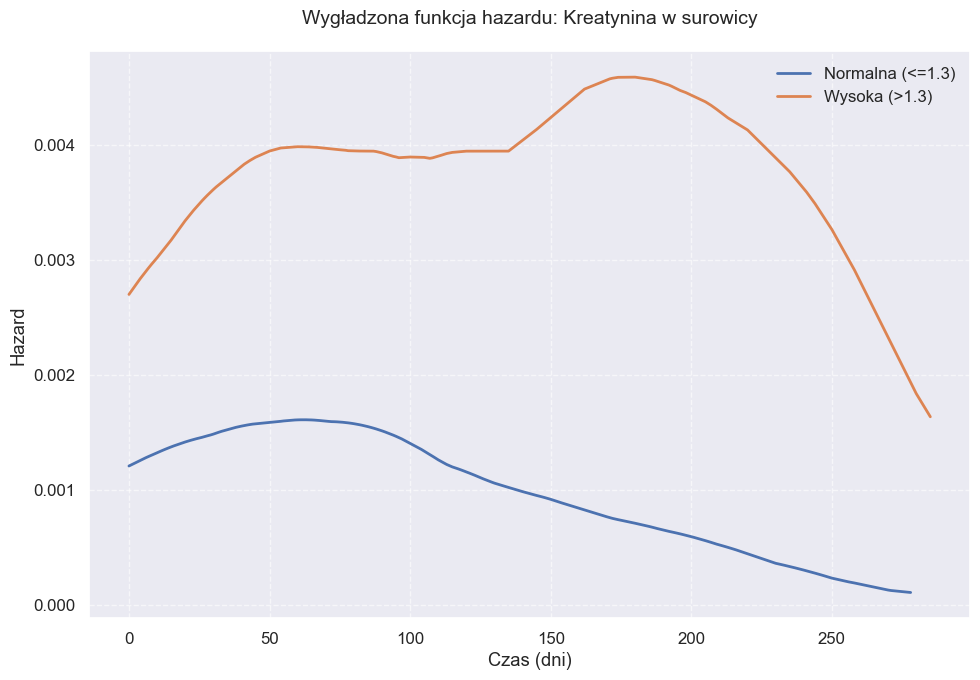

In [17]:
df['creatinine_cat'] = pd.cut(df['serum_creatinine'], bins=[0, 1.3, 10], labels=[0, 1])
ksztalt_hazardu_grup(df, 'creatinine_cat', {0: 'Normalna (<=1.3)', 1: 'Wysoka (>1.3)'}, 'Kreatynina w surowicy')


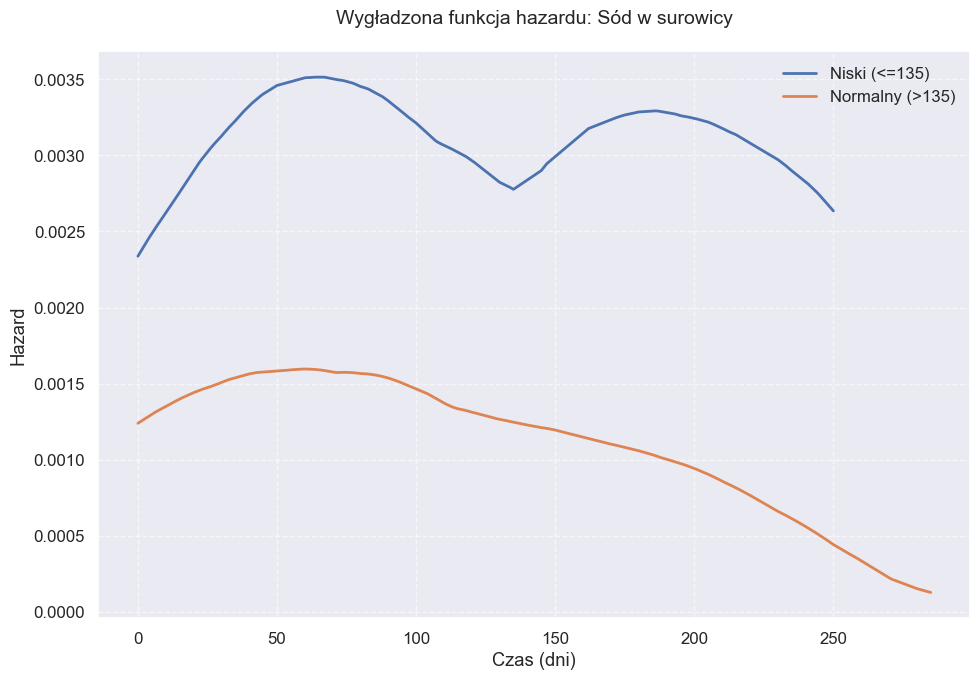

In [18]:
df['sodium_cat'] = pd.cut(df['serum_sodium'], bins=[0, 135, 150], labels=[0, 1])
ksztalt_hazardu_grup(df, 'sodium_cat', {0: 'Niski (<=135)', 1: 'Normalny (>135)'}, 'Sód w surowicy')


In [ ]:
def weryfikacja_graficzna_rozkladow(df, time_col='time', event_col='DEATH_EVENT'):
    """
    Funkcja generuje wykresy diagnostyczne dla rozkładu Wykładniczego i Weibulla
    na podstawie estymatora Kaplana-Meiera.
    """
    kmf_pop = KaplanMeierFitter()
    kmf_pop.fit(df[time_col], df[event_col])

    # Wyciągamy czas i przeżycie S(t), omijając t=0 dla logarytmów
    times = kmf_pop.survival_function_.index.values[1:]
    survival_probs = kmf_pop.survival_function_['KM_estimate'].values[1:]

    plt.figure(figsize=(14, 6))

    # Wykres 1: Rozkład Wykładniczy (-ln(S(t)) vs t)
    plt.subplot(1, 2, 1)
    cum_hazard = -np.log(survival_probs)
    plt.plot(times, cum_hazard, marker='o', linestyle='', color='blue', alpha=0.7)
    
    # Linia trendu przechodząca przez (0,0)
    slope = np.linalg.lstsq(times[:, np.newaxis], cum_hazard, rcond=None)[0][0]
    plt.plot(times, slope * times, color='red', linestyle='--', label='Idealny trend wykładniczy')
    
    plt.title('Ocena rozkładu Wykładniczego\n-ln(S(t)) vs Czas')
    plt.xlabel('Czas t (dni)')
    plt.ylabel('Skumulowany hazard: -ln(S(t))')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Wykres 2: Rozkład Weibulla (ln(-ln(S(t))) vs ln(t))
    plt.subplot(1, 2, 2)
    valid_idx = survival_probs < 1.0 # Omijamy S(t)=1
    log_times = np.log(times[valid_idx])
    log_log_surv = np.log(-np.log(survival_probs[valid_idx]))

    plt.plot(log_times, log_log_surv, marker='s', linestyle='', color='green', alpha=0.7)
    
    # Regresja liniowa dla trendu Weibulla
    m, b = np.polyfit(log_times, log_log_surv, 1)
    plt.plot(log_times, m * log_times + b, color='red', linestyle='--', label='Idealny trend Weibulla')

    plt.title('Ocena rozkładu Weibulla\nln(-ln(S(t))) vs ln(t)')
    plt.xlabel('ln(Czas)')
    plt.ylabel('ln(-ln(S(t)))')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

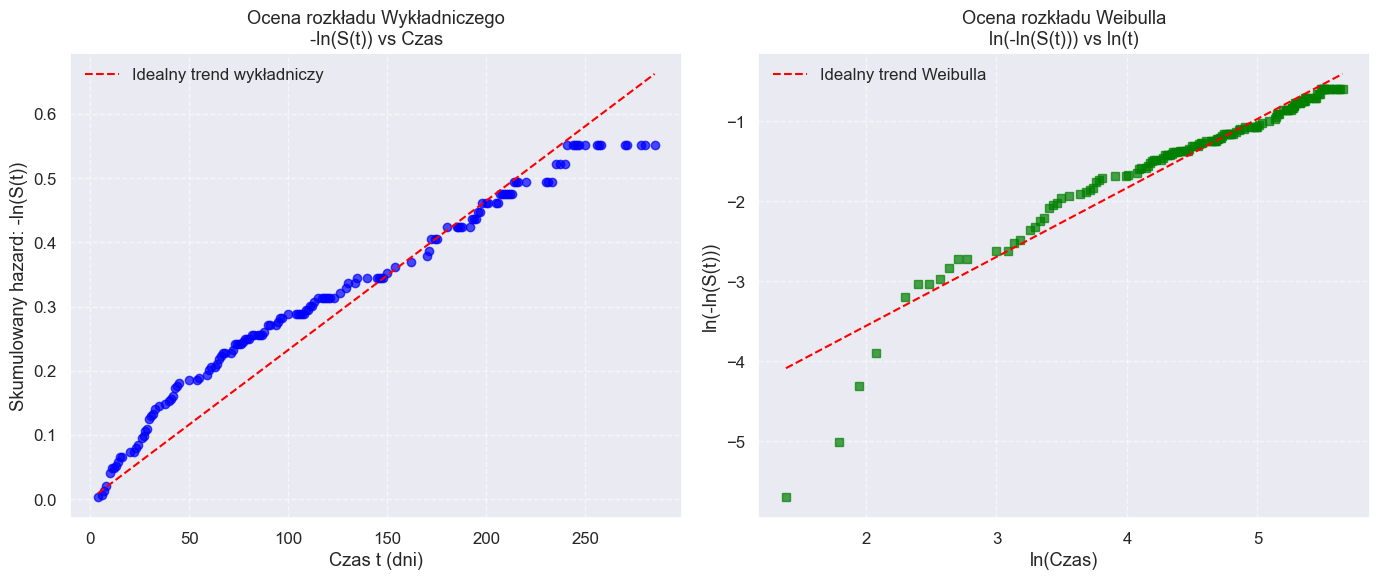

In [20]:
weryfikacja_graficzna_rozkladow(df)

In [25]:
def oblicz_r2_dopasowania(df, time_col='time', event_col='DEATH_EVENT'):
    """
    Oblicza współczynnik determinacji R^2 dla modeli Wykładniczego i Weibulla.
    Im bliżej 1.0, tym lepsze dopasowanie modelu do danych empirycznych K-M.
    """
    
    kmf_pop = KaplanMeierFitter()
    kmf_pop.fit(df[time_col], df[event_col])

    times = kmf_pop.survival_function_.index.values[1:]
    survival_probs = kmf_pop.survival_function_['KM_estimate'].values[1:]

    # 1. Model Wykładniczy
    y_true_exp = -np.log(survival_probs)
    slope = np.linalg.lstsq(times[:, np.newaxis], y_true_exp, rcond=None)[0][0]
    y_pred_exp = slope * times
    r2_exp = r2_score(y_true_exp, y_pred_exp)

    # 2. Model Weibulla
    valid_idx = survival_probs < 1.0
    y_true_weibull = np.log(-np.log(survival_probs[valid_idx]))
    log_times = np.log(times[valid_idx])
    m, b = np.polyfit(log_times, y_true_weibull, 1)
    y_pred_weibull = m * log_times + b
    r2_weibull = r2_score(y_true_weibull, y_pred_weibull)

    print(f"Obiektywne dopasowanie modeli (R^2):")
    print(f"- Model Wykładniczy (Exponential): {r2_exp:.4f}")
    print(f"- Model Weibulla (Weibull):       {r2_weibull:.4f}")
    
    return r2_exp, r2_weibull

# Wywołanie:
oblicz_r2_dopasowania(df)


Obiektywne dopasowanie modeli (R^2):
- Model Wykładniczy (Exponential): 0.9136
- Model Weibulla (Weibull):       0.9297


(0.9135861514976032, 0.9297434658570719)